<a href="https://colab.research.google.com/github/Sbolivar16/MolecularDocking/blob/main/GNINA_and_Vina_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 **Comparative Analysis of Molecular Docking with AutoDock Vina and GNINA: Extraction, Visualization, and Affinity Evaluation**

<div align="center">

🧪 **Santiago Bolívar A.**  
**Chemist, M.Sc., Ph.D.**  
📍 *National University of Rosario, Argentina*  
🔗 [GitHub Profile](https://github.com/Sbolivar16)

</div>

---

This Google Colab notebook is designed to facilitate the analysis of **molecular docking results** generated with **AutoDock Vina** and **GNINA**, two of the most widely used tools in structure-based drug discovery workflows.

Both programs estimate the binding affinity between ligands and a target protein. However, GNINA enhances traditional docking by incorporating **deep learning models**, specifically convolutional neural networks (CNNs), to improve pose prediction and scoring accuracy. In contrast, AutoDock Vina employs classical scoring functions based on molecular mechanics.

This notebook allows you to:

- 📥 Process `.log` files generated by Vina and GNINA.
- 🧾 Automatically extract key information:
  - For **Vina**: `ligand`, `affinity`, `rmsd lb`, `rmsd ub`.
  - For **GNINA**: `ligand`, `affinity`, `intramolecular energy`, `cnn pose score`, `cnn affinity`.
- 🎯 Filter the **top-ranked pose (mode 1)** for each ligand.
- 📊 Visualize results through insightful plots.
- 📈 Perform linear regression analysis and compute the $R^2$ coefficient.

---

### 🔍 Key Features

- **🧾 Automated parsing of multiple `.log` files**  
  Compatible with files uploaded via Google Colab, supporting both Vina and GNINA output formats.

- **📋 Interactive data tables**  
  For fast filtering, inspection, and sorting of docking results per ligand.

- **📉 Customizable exploratory visualizations**  
  - Histogram of binding affinities  
  - Sorted barplots of ligands by affinity  
  - Top 10 ligand affinity overview  
  - Scatter plot with regression line and $R^2$ value

- **📤 Optional CSV export**  
  For further analysis or integration with other pipelines.

---

> ⚠️ **Note:** This notebook assumes that `.log` files follow the standard output structure of **AutoDock Vina** or **GNINA**, and that ligand names are correctly specified in the input command lines.



**Example of .logs from Gnina and Autodock Vina**
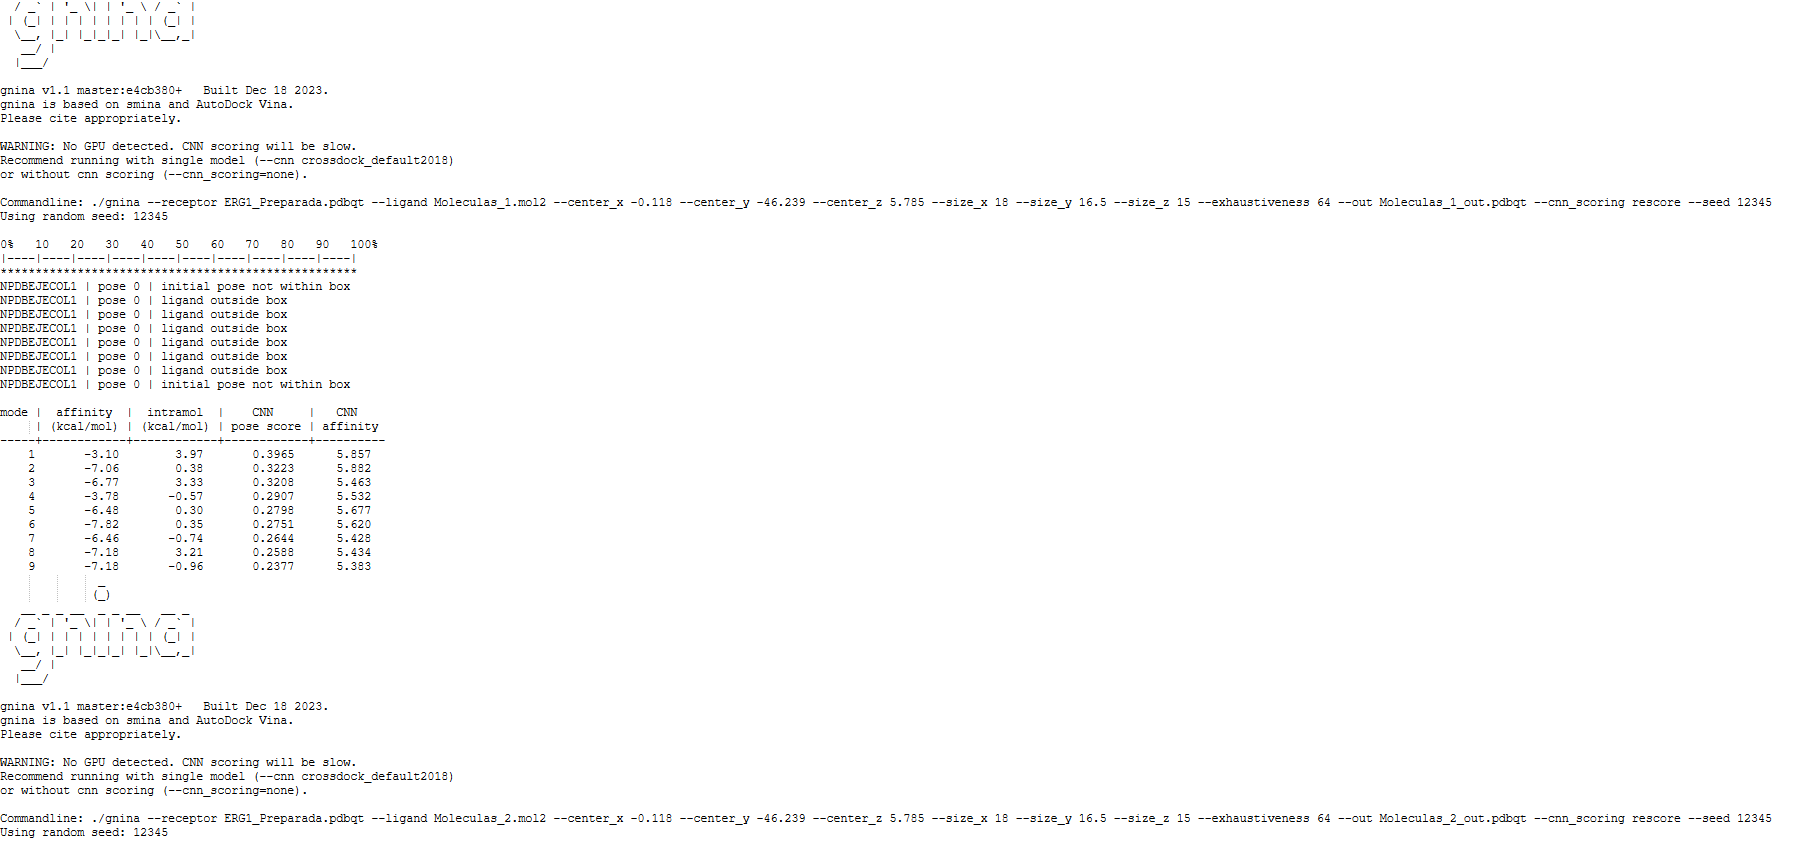

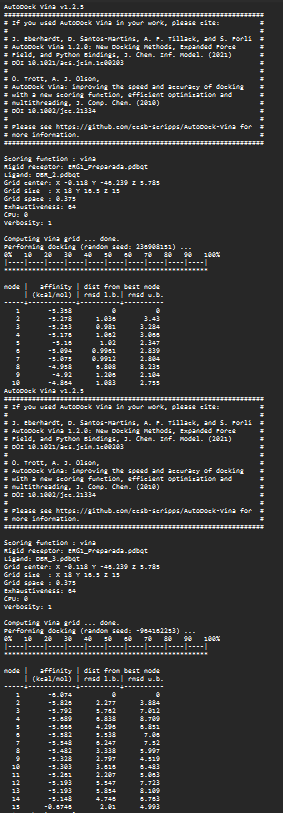



In [33]:
# Step 1: Upload .log files
from google.colab import files
import io
import pandas as pd
import re

uploaded = files.upload()


Saving Docking.log to Docking (3).log
Saving docking.sh to docking.sh
Saving Docking_2_productosaturales.log to Docking_2_productosaturales (3).log


In [39]:
# Step 2: Function to extract data from all GNINA blocks
def extract_gnina_data(file_content, file_name):
    ligand_pattern = re.compile(r"--ligand\s+(\S+\.mol2)")
    entry_pattern = re.compile(r"^\s*(\d+)\s+(-?\d+(?:\.\d+)?)\s+(-?\d+(?:\.\d+)?)\s+(\d+(?:\.\d+)?)\s+(\d+(?:\.\d+)?)")

    results = []
    ligand_name = "Unknown"

    for line in file_content:
        try:
            line = line.decode('utf-8').strip()
        except:
            continue  # Skip lines with decoding errors

        # Detect ligand name
        ligand_match = ligand_pattern.search(line)
        if ligand_match:
            ligand_name = ligand_match.group(1).split('.')[0]

        # Extract table entries
        entry_match = entry_pattern.match(line)
        if entry_match:
            mode, aff, intramol, cnn_pose, cnn_aff = entry_match.groups()
            results.append({
                "ligand": ligand_name,
                "mode": int(mode),
                "affinity": float(aff),
                "intra_molecular": float(intramol),
                "cnn_pose_score": float(cnn_pose),
                "cnn_affinity": float(cnn_aff),
                "file": file_name
            })

    return results

# Step 3: Extract and concatenate all results into df
all_results = []
for file_name, file in uploaded.items():
    content = io.BytesIO(file).readlines()
    all_results.extend(extract_gnina_data(content, file_name))

df = pd.DataFrame(all_results)  # 🔁 now df exists!

# Step 4: Filter only mode 1 and display table
df_pose1 = df[df['mode'] == 1].reset_index(drop=True)

# Optional: Display info
print(f"🎯 Entries with mode 1: {len(df_pose1)}")
print(f"🧪 Unique ligands: {df_pose1['ligand'].nunique()}")

# Step 5: Interactive table
from google.colab import data_table
data_table.DataTable(df_pose1, include_index=False, num_rows_per_page=15)


🎯 Entries with mode 1: 235
🧪 Unique ligands: 235


,ligand,mode,affinity,intra_molecular,cnn_pose_score,cnn_affinity,file
0,Moleculas_1,1,-3.10,3.97,0.3965,5.857,Docking (3).log
1,Moleculas_2,1,-6.99,-0.31,0.4349,6.036,Docking (3).log
2,Moleculas_3,1,-8.37,-0.19,0.5772,5.972,Docking (3).log
3,Moleculas_4,1,-9.39,-0.36,0.4071,5.648,Docking (3).log
4,Moleculas_5,1,-8.91,-0.21,0.4488,5.404,Docking (3).log
...,...,...,...,...,...,...,...
230,Moleculas_232,1,-5.86,0.00,0.5602,3.856,Docking_2_productosaturales (3).log
231,Moleculas_233,1,-10.23,0.73,0.1698,5.961,Docking_2_productosaturales (3).log
232,Moleculas_234,1,-11.41,21.52,0.1521,4.630,Docking_2_productosaturales (3).log
233,Moleculas_235,1,-7.61,0.97,0.4019,4.908,Docking_2_productosaturales (3).log


In [40]:
# Save as CSV file
df_pose1.to_csv("poses_mode1.csv", index=False)

# Download in the browser
from google.colab import files
files.download("poses_mode1.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🧪 For .log files from AutoDock Vina

In [41]:
# 🧪 Step 1: Upload `.log` files from AutoDock Vina
from google.colab import files
import io
import pandas as pd
import re

uploaded = files.upload()




Saving Docking_ERG1_vina.log to Docking_ERG1_vina (2).log


In [42]:
# Translate column names from Spanish to English (if needed)
translation_dict = {
    "ligando": "ligand",
    "modo": "mode",
    "afinidad": "affinity",
    "archivo": "file",
    "rmsd_lb": "rmsd_lb",
    "rmsd_ub": "rmsd_ub"
}

df = df.rename(columns=translation_dict)

# Optional: verify the result
print(f"✅ Translated columns: {list(df.columns)}")


✅ Translated columns: ['ligand', 'mode', 'affinity', 'intra_molecular', 'cnn_pose_score', 'cnn_affinity', 'file']


In [43]:
def extract_vina_data(file_content, file_name):
    results = []
    ligand_name = "Unknown"

    # Pattern to capture ligand name and poses
    ligand_line_pattern = re.compile(r"Ligand:\s+(\S+\.pdbqt)")
    entry_pattern = re.compile(r"^\s*(\d+)\s+(-?\d+(?:\.\d+)?)\s+(\d+(?:\.\d+)?)\s+(\d+(?:\.\d+)?)")

    for line in file_content:
        try:
            line = line.decode('utf-8').strip()
        except:
            continue

        # Extract ligand name
        match_lig = ligand_line_pattern.search(line)
        if match_lig:
            ligand_name = match_lig.group(1).replace(".pdbqt", "")

        # Extract pose data
        match = entry_pattern.match(line)
        if match:
            mode, aff, rmsd_lb, rmsd_ub = match.groups()
            results.append({
                "ligand": ligand_name,
                "mode": int(mode),
                "affinity": float(aff),
                "rmsd_lb": float(rmsd_lb),
                "rmsd_ub": float(rmsd_ub),
                "file": file_name
            })

    return results


In [44]:
all_data = []

for file_name, file in uploaded.items():
    content = io.BytesIO(file).readlines()
    data = extract_vina_data(content, file_name)  # assumes you're using the English version of the function
    all_data.extend(data)

df_vina = pd.DataFrame(all_data)

print(f"🧬 Total entries: {len(df_vina)}")
print(f"🔢 Unique ligands: {df_vina['ligand'].nunique()}")
print(f"🧾 Example ligands: {df_vina['ligand'].unique()[:5]}")

from google.colab import data_table
data_table.DataTable(df_vina[df_vina['mode'] == 1], include_index=False, num_rows_per_page=15)



🧬 Total entries: 436
🔢 Unique ligands: 24
🧾 Example ligands: ['DBR_1' 'DBR_2' 'DBR_3' 'DBR_4' 'DBR_5']


,ligand,mode,affinity,rmsd_lb,rmsd_ub,file
0,DBR_1,1,-5.454,0.0,0.0,Docking_ERG1_vina (2).log
10,DBR_2,1,-5.358,0.0,0.0,Docking_ERG1_vina (2).log
20,DBR_3,1,-6.074,0.0,0.0,Docking_ERG1_vina (2).log
35,DBR_4,1,-6.201,0.0,0.0,Docking_ERG1_vina (2).log
50,DBR_5,1,-6.465,0.0,0.0,Docking_ERG1_vina (2).log
65,DBR_6,1,-5.912,0.0,0.0,Docking_ERG1_vina (2).log
80,DBR_7,1,-6.461,0.0,0.0,Docking_ERG1_vina (2).log
95,DBR_8,1,-6.973,0.0,0.0,Docking_ERG1_vina (2).log
109,DBR_9,1,-6.927,0.0,0.0,Docking_ERG1_vina (2).log
129,DBR_10,1,-7.288,0.0,0.0,Docking_ERG1_vina (2).log


In [46]:
# Filter only the first pose (mode 1)
df_vina_pose1 = df_vina[df_vina['mode'] == 1].reset_index(drop=True)

# Save as CSV file
df_vina_pose1.to_csv("vina_poses_mode1.csv", index=False)

# Download the CSV file
from google.colab import files
files.download("vina_poses_mode1.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

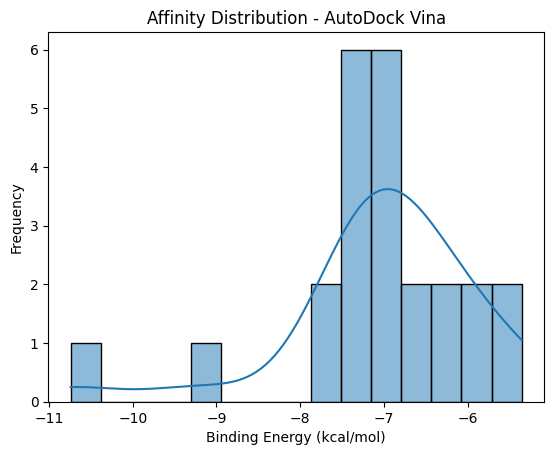

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("vina_poses_mode1.csv")

sns.histplot(df['affinity'], bins=15, kde=True)
plt.title("Affinity Distribution - AutoDock Vina")
plt.xlabel("Binding Energy (kcal/mol)")
plt.ylabel("Frequency")
plt.show()


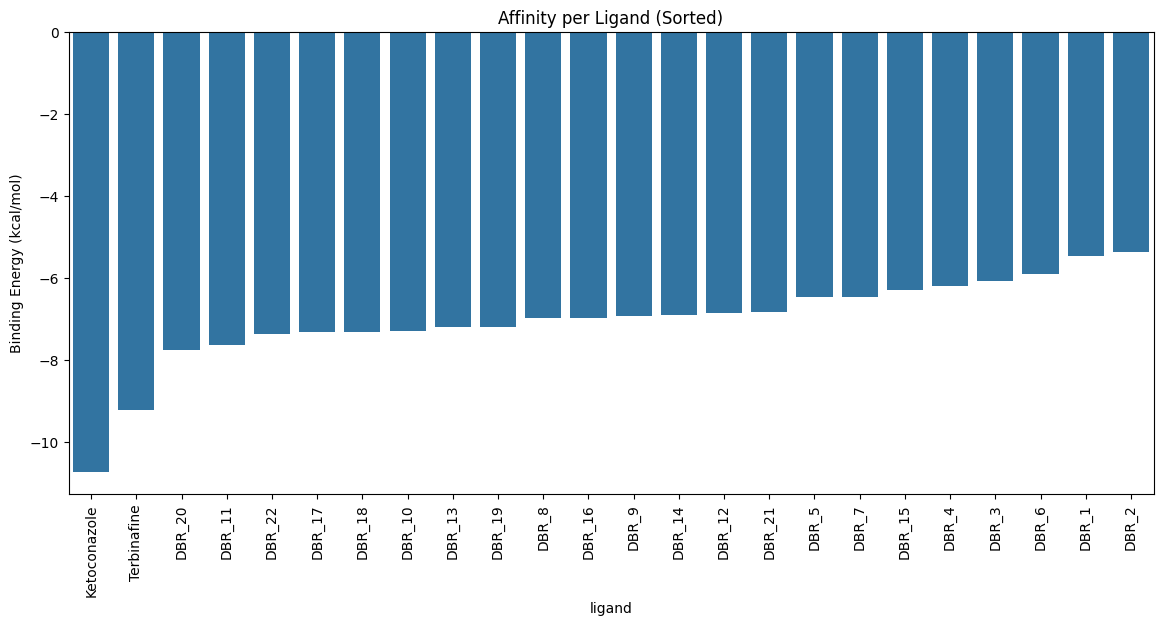

In [48]:
df_sorted = df.sort_values('affinity')  # more negative is better
plt.figure(figsize=(14, 6))
sns.barplot(x='ligand', y='affinity', data=df_sorted)
plt.xticks(rotation=90)
plt.title("Affinity per Ligand (Sorted)")
plt.ylabel("Binding Energy (kcal/mol)")
plt.show()



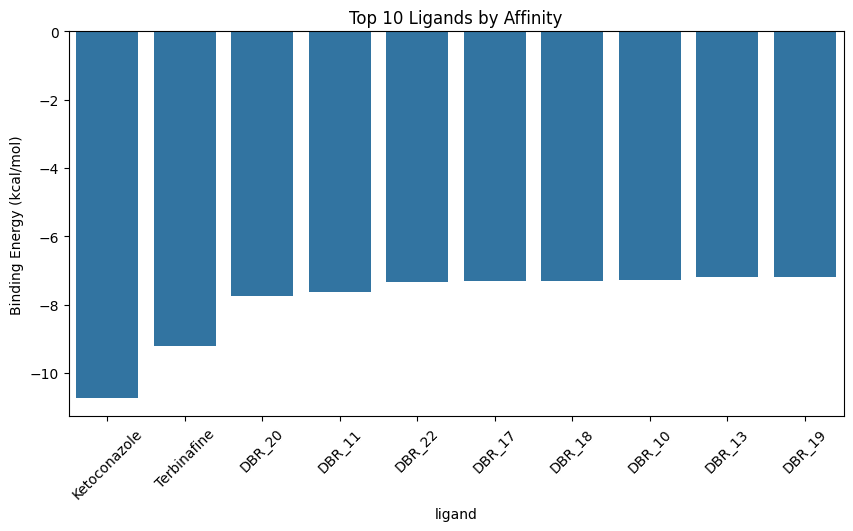

In [49]:
top10 = df_sorted.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='ligand', y='affinity', data=top10)
plt.title("Top 10 Ligands by Affinity")
plt.xticks(rotation=45)
plt.ylabel("Binding Energy (kcal/mol)")
plt.show()



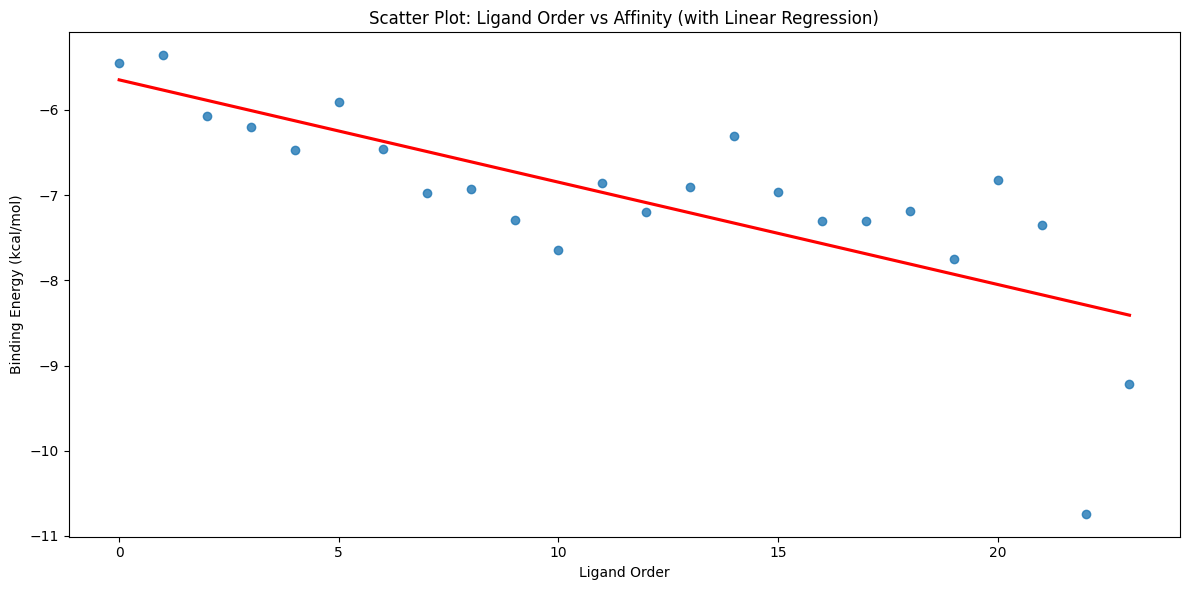

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("vina_poses_mode1.csv")
df = df.reset_index().rename(columns={"index": "order"})

plt.figure(figsize=(12, 6))
sns.regplot(x="order", y="affinity", data=df, ci=None, line_kws={'color': 'red'})
plt.title("Scatter Plot: Ligand Order vs Affinity (with Linear Regression)")
plt.xlabel("Ligand Order")
plt.ylabel("Binding Energy (kcal/mol)")
plt.grid(False)
plt.tight_layout()
plt.show()
